# Verificación de locutor de texto dependiente

Proyecto de la asignatura **Biometría de la Voz**. El objetivo es construir un
sistema que, dado un audio de una persona diciendo una frase corta
predefinida, sea capaz de:

1. **Identificar al locutor** — ¿quién está hablando? (Red 1)
2. **Verificar la frase** — ¿ha dicho la frase esperada? (Red 2)

Y, combinando ambas, **verificar** una afirmación binaria del tipo *"soy el
locutor L diciendo la frase F"* — el corazón del trabajo.

Este notebook es el *orquestador*: no contiene la lógica interna, solo llama
en orden a las funciones de los módulos `src/data.py`, `src/model.py`,
`src/train.py` y `src/verificacion.py`, y muestra los resultados.

## Base de datos

Usamos `TextDependentSpeakerIdentification`: 816 locutores que pronuncian 5
frases cortas predefinidas (S1–S5), unos 45.000 audios en total a 16 kHz.

Por viabilidad computacional (RTX 3060 Laptop, 6 GB) trabajamos con un
**subconjunto de 50 locutores**, seleccionados como los que más audios tienen
en la base de datos (criterio `"mas_audios"`). Esto evita el desbalance que
introducía una selección alfabética: algunos locutores tenían 5 audios y
otros 174, lo que sesgaba el aprendizaje hacia los locutores grandes.

Con los 50 seleccionados nos quedan unos **7.500 audios** repartidos en:

- **50 clases de locutor** para la Red 1.
- **5 clases de frase** (S1–S5) para la Red 2.

## 1. Preparación del entorno y carga de datos

Importamos los módulos del proyecto. La línea `sys.path.append("src")` le
dice a Python que busque también en la carpeta `src/`, donde están los
módulos.

A continuación cargamos el dataset. Procesar los ~7.500 audios (leer cada
WAV y extraer sus MFCC) tarda un par de minutos, así que usamos una
**caché**: la primera vez se procesa todo y se guarda en
`cache_dataset.npz`; las siguientes veces se carga directamente, en
segundos.

> Si cambias el subconjunto de locutores (`N_LOCUTORES` o el criterio),
> borra antes `cache_dataset.npz` para forzar la regeneración.

In [18]:
import sys, os
sys.path.append("src")

import numpy as np
import data, model, train, verificacion

CACHE = "cache_dataset.npz"
N_LOCUTORES = 50

if os.path.exists(CACHE):
    d = np.load(CACHE, allow_pickle=True)
    X, y_loc, y_pin = d["X"], d["y_loc"], d["y_pin"]
    mapas     = d["mapas"].item()
    registros = d["registros"].tolist()
    print("Dataset cargado de la caché:", X.shape)
else:
    registros = data.construir_indice(max_locutores=N_LOCUTORES,
                                      criterio="mas_audios")
    X, y_loc, y_pin, mapas = data.construir_dataset(registros)
    np.savez(CACHE, X=X, y_loc=y_loc, y_pin=y_pin,
             mapas=mapas, registros=registros)
    print("Dataset procesado y guardado en caché:", X.shape)

Dataset cargado de la caché: (7574, 120, 63, 1)


In [19]:
# Comprobación de coherencia: que la caché coincide con lo esperado
print(f"Audios totales : {X.shape[0]}")
print(f"Forma MFCC     : {X.shape[1:]}  (n_caract, T, canal)")
print(f"Locutores      : {len(mapas['locutor'])}  (esperados: {N_LOCUTORES})")
print(f"Frases         : {len(mapas['pin'])}      (esperadas: 5)")

assert len(mapas["locutor"]) == N_LOCUTORES, \
    "La caché no coincide con N_LOCUTORES. ¿Has olvidado borrar cache_dataset.npz?"
assert len(mapas["pin"]) == 5, "Esperábamos 5 frases (S1–S5)."

Audios totales : 7574
Forma MFCC     : (120, 63, 1)  (n_caract, T, canal)
Locutores      : 50  (esperados: 50)
Frases         : 5      (esperadas: 5)


## 2. Red 1 — Identificación del locutor

La primera red responde a la pregunta *"¿quién está hablando?"*. Es una
**CNN** (red convolucional) con **50 salidas**, una por cada locutor del
subconjunto.

### 2.1 División de los datos

Dividimos los audios en tres grupos:

- **Train (70 %)**: la red aprende con ellos.
- **Validación (15 %)**: vigilamos el entrenamiento sin que la red aprenda
  de ellos; sirve para detectar sobreajuste.
- **Test (15 %)**: no se tocan hasta el final; dan la medida honesta del
  rendimiento.

La división es **estratificada por locutor**: cada locutor aparece en los
tres grupos en la misma proporción. Dividimos los *registros* (rutas de
fichero), no los MFCC ya calculados, porque así podemos aplicar el aumento
de datos sobre los audios crudos antes de extraer sus características.

In [20]:
reg_train, reg_val, reg_test = data.dividir_registros(registros, campo="locutor")

Registros divididos -> train: 5301  |  val: 1136  |  test: 1137


### 2.2 Aumento de datos (solo en train)

Para combatir el sobreajuste, generamos variaciones artificiales de los
audios de entrenamiento (ruido suave, desplazamiento temporal, cambio de
velocidad). Por cada audio original se crean **2 copias aumentadas**, así
la red ve el triple de ejemplos y se ve forzada a generalizar.

**No usamos cambio de tono (pitch shift)** a propósito: el tono es un
rasgo de la identidad del locutor, y desplazarlo difuminaría justo lo que
esta red debe aprender.

**El aumento se aplica solo a train.** Validación y test se procesan sin
aumento, para que midan el rendimiento sobre audios reales y la métrica
sea honesta.

In [21]:
print("Construyendo train (con aumento)...")
Xtr, ytr, ytr_pin = data.construir_dataset_desde_registros(
    reg_train, mapas, aumentar=True, n_aug=2)

print("\nConstruyendo validación...")
Xv, yv, yv_pin = data.construir_dataset_desde_registros(
    reg_val, mapas, aumentar=False)

print("\nConstruyendo test...")
Xte, yte, yte_pin = data.construir_dataset_desde_registros(
    reg_test, mapas, aumentar=False)

print(f"\nTrain: {Xtr.shape}  |  Val: {Xv.shape}  |  Test: {Xte.shape}")

Construyendo train (con aumento)...
  Procesando audio 0/5301...
  Procesando audio 250/5301...
  Procesando audio 500/5301...
  Procesando audio 750/5301...
  Procesando audio 1000/5301...
  Procesando audio 1250/5301...
  Procesando audio 1500/5301...
  Procesando audio 1750/5301...
  Procesando audio 2000/5301...
  Procesando audio 2250/5301...
  Procesando audio 2500/5301...
  Procesando audio 2750/5301...
  Procesando audio 3000/5301...
  Procesando audio 3250/5301...
  Procesando audio 3500/5301...
  Procesando audio 3750/5301...
  Procesando audio 4000/5301...
  Procesando audio 4250/5301...
  Procesando audio 4500/5301...
  Procesando audio 4750/5301...
  Procesando audio 5000/5301...
  Procesando audio 5250/5301...
  Construido: (15903, 120, 63, 1) (con aumento x2)

Construyendo validación...
  Procesando audio 0/1136...
  Procesando audio 250/1136...
  Procesando audio 500/1136...
  Procesando audio 750/1136...
  Procesando audio 1000/1136...
  Construido: (1136, 120, 63, 1)


### 2.3 Creación y entrenamiento del modelo

Creamos la CNN con `model.construir_modelo`. Le pasamos:

- `"cnn"`: el tipo de arquitectura (la otra opción es `"cnn_lstm"`).
- `input_shape`: la forma de cada audio (n.º de características × tiempo × canal).
- `n_clases=50`: una salida por locutor.

**Patrón "entrena o carga"**: si el modelo ya está guardado en
`resultados/red1_locutor.keras`, lo cargamos desde disco (segundos).
Si no, entrenamos desde cero (~20 minutos en la RTX 3060). Esto hace el
notebook reproducible end-to-end pero rápido en iteraciones siguientes.

Configuración de entrenamiento ajustada al problema:

- **`monitor="val_loss"`**: con 50 clases la curva de `val_accuracy` es muy
  ruidosa (un audio mal cambia ~0.09 puntos); la pérdida es una métrica
  continua y mucho más estable para decidir cuándo parar.
- **`patience=20`** y `epochs=100`: damos margen al EarlyStopping para que
  no corte en una época bajona casual.
- **`batch_size=64`**: gradientes más estables que con 32.

In [22]:
from tensorflow.keras.models import load_model

RUTA_RED1 = "resultados/red1_locutor.keras"
hist1 = None  # objeto History solo existe si entrenamos en esta sesión

if os.path.exists(RUTA_RED1):
    red1 = load_model(RUTA_RED1)
    print(f"Red 1 cargada de disco: {red1.name}, {red1.count_params():,} parámetros")
else:
    cfg_red1 = {
        "batch_size":    64,
        "epochs":        100,
        "learning_rate": 1e-3,
        "patience":      20,
        "monitor":       "val_loss",
        "results_dir":   "resultados",
    }
    red1 = model.construir_modelo("cnn", input_shape=X.shape[1:], n_clases=50)
    hist1 = train.entrenar(red1, Xtr, ytr, Xv, yv,
                           cfg=cfg_red1, ruta_modelo=RUTA_RED1)

Red 1 cargada de disco: CNN, 116,530 parámetros


### 2.4 Evaluación de la Red 1

Evaluamos sobre el conjunto de **test** — audios que la red no ha visto
nunca. El resultado en test es la medida honesta del rendimiento.

Mostramos:

- **Accuracy global** y informe por clase (precision, recall, f1-score).
- **Matriz de confusión**: con 50 clases las anotaciones numéricas no
  caben dentro de las casillas, pero la diagonal se lee bien por color
  (`train.py` desactiva `annot` automáticamente si hay más de 25 clases).
- **Curvas de entrenamiento** (solo si el modelo se ha entrenado en esta
  sesión, no si se cargó de disco).

I0000 00:00:1779740565.990902     189 service.cc:146] XLA service 0x7b6570001800 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779740565.990933     189 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-05-25 20:22:46.019239: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-25 20:22:46.120608: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906
I0000 00:00:1779740567.756221     189 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



=== Evaluación en TEST ===
  Pérdida  : 1.1029
  Accuracy : 69.83%

              precision    recall  f1-score   support

  spk_000008       0.83      0.73      0.78        26
  spk_000010       0.92      0.58      0.71        19
  spk_000014       0.47      0.95      0.63        19
  spk_000031       0.58      0.96      0.72        23
  spk_000067       0.83      0.23      0.36        22
  spk_000079       0.80      0.67      0.73        18
  spk_000113       0.53      0.95      0.68        19
  spk_000120       1.00      0.50      0.67        18
  spk_000125       0.89      0.94      0.92        18
  spk_000141       0.92      0.57      0.71        21
  spk_000149       0.68      0.96      0.80        27
  spk_000174       0.92      0.44      0.59        25
  spk_000193       0.61      0.92      0.73        24
  spk_000195       0.92      0.60      0.73        20
  spk_000197       1.00      0.25      0.40        20
  spk_000210       0.38      0.38      0.38        21
  spk_000212

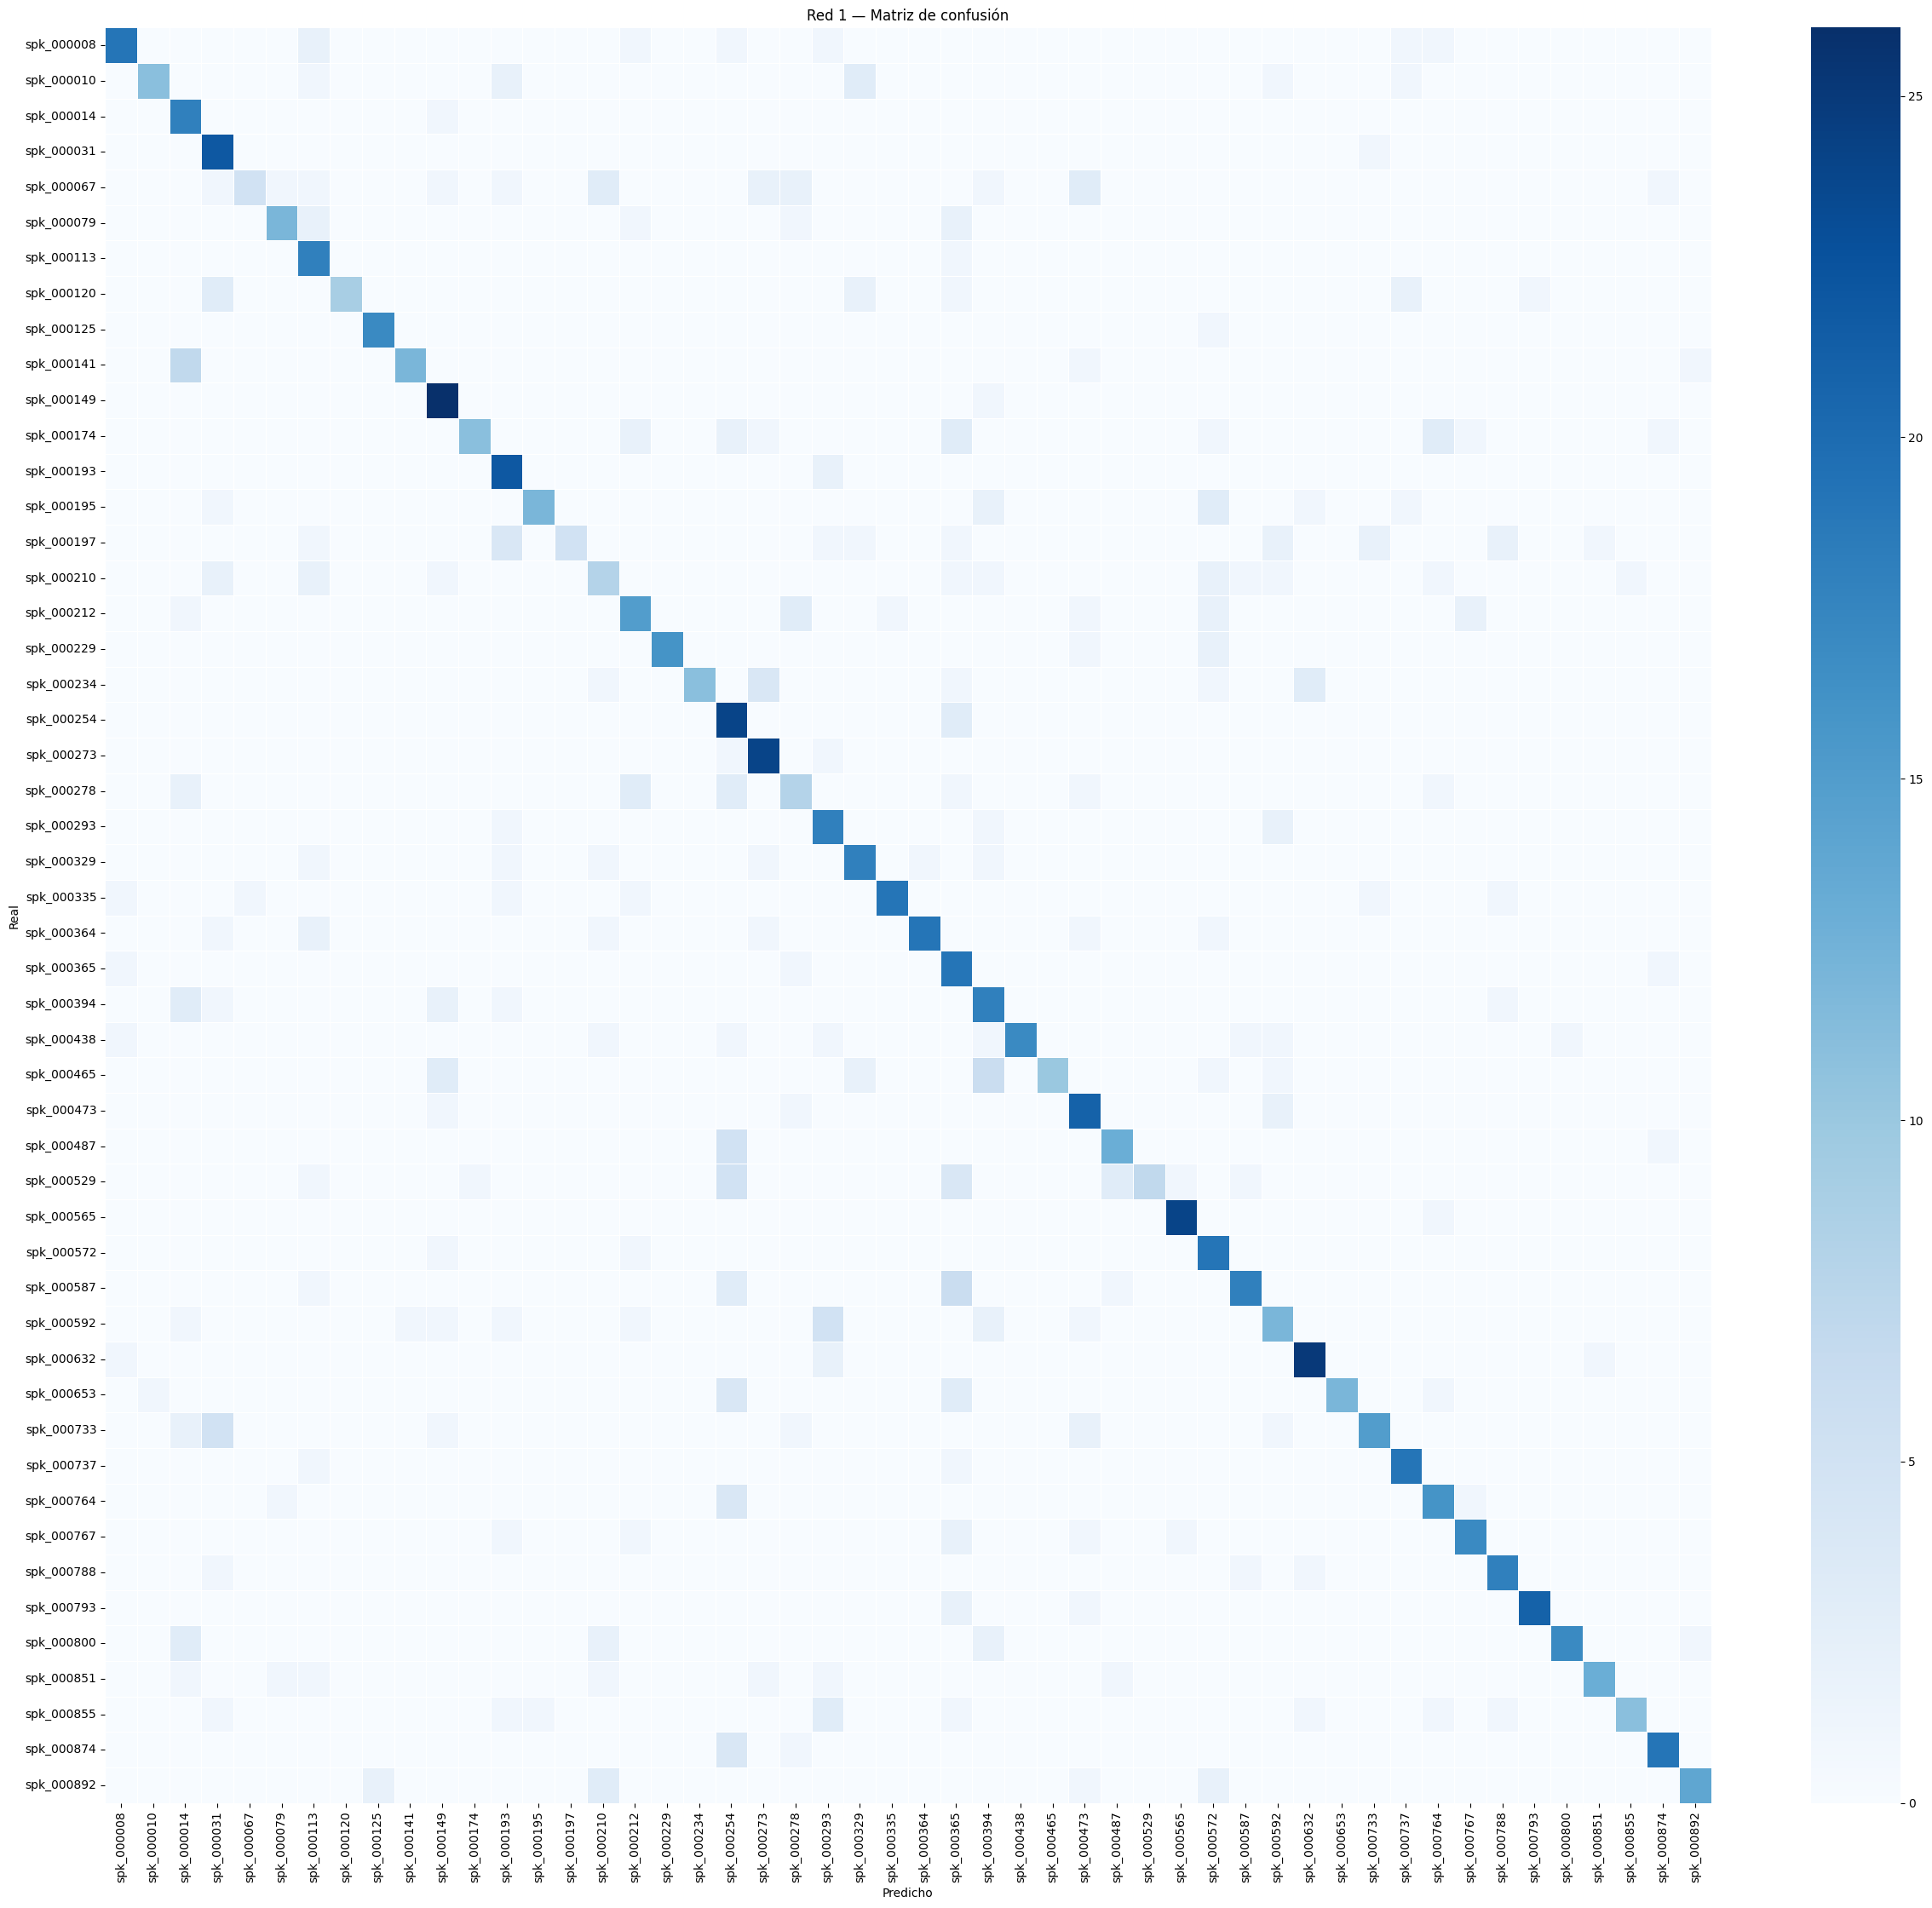

In [6]:
nombres_loc = sorted(mapas["locutor"].keys())

res1 = train.evaluar(red1, Xte, yte, nombres_clases=nombres_loc)

if hist1 is not None:
    train.graficar_entrenamiento(
        hist1, titulo="Red 1 — Identificación de locutor",
        guardar="resultados/red1_curvas.png",
    )

train.graficar_matriz_confusion(
    res1, nombres_loc,
    titulo="Red 1 — Matriz de confusión",
    guardar="resultados/red1_matriz.png",
)

## 3. Red 2 — Verificación de la frase

La segunda red responde a la pregunta *"¿qué frase se ha dicho?"*. Es una
**CNN** con **5 salidas**, una por cada frase de la base de datos (S1–S5).

Reutilizamos los mismos audios que en la Red 1: la diferencia está en la
etiqueta. Donde la Red 1 usaba la etiqueta de locutor, la Red 2 usa la
etiqueta de frase.

### 3.1 División de los datos

Volvemos a dividir los registros en train / val / test, pero esta vez
**estratificando por frase** (`campo="pin"`): cada frase debe aparecer
proporcionalmente en los tres grupos.

Una consecuencia importante de cambiar el criterio: un locutor concreto
puede caer entero en train o entero en test. Eso es justo lo que queremos,
porque la Red 2 tiene que reconocer qué frase se dice **independientemente
de quién la diga**, incluso si nunca había oído a ese locutor — la
propiedad de "generalización a locutores nuevos".

In [23]:
reg_train2, reg_val2, reg_test2 = data.dividir_registros(registros, campo="pin")

Registros divididos -> train: 5301  |  val: 1136  |  test: 1137


### 3.2 Construcción de los datasets

Esta vez **no usamos aumento de datos**: con 5 clases y ~500 audios por
clase tenemos margen de sobra, el problema ya no es la falta de datos.

Usamos las etiquetas de PIN (`ytr2_pin`, `yv2_pin`, `yte2_pin`) que devuelve
`construir_dataset_desde_registros` — la función ya nos las prepara en una
sola pasada.

In [24]:
print("Construyendo train...")
Xtr2, ytr2_loc, ytr2_pin = data.construir_dataset_desde_registros(
    reg_train2, mapas, aumentar=False)

print("\nConstruyendo validación...")
Xv2, yv2_loc, yv2_pin = data.construir_dataset_desde_registros(
    reg_val2, mapas, aumentar=False)

print("\nConstruyendo test...")
Xte2, yte2_loc, yte2_pin = data.construir_dataset_desde_registros(
    reg_test2, mapas, aumentar=False)

print(f"\nTrain: {Xtr2.shape}  |  Val: {Xv2.shape}  |  Test: {Xte2.shape}")

Construyendo train...
  Procesando audio 0/5301...
  Procesando audio 250/5301...
  Procesando audio 500/5301...
  Procesando audio 750/5301...
  Procesando audio 1000/5301...
  Procesando audio 1250/5301...
  Procesando audio 1500/5301...
  Procesando audio 1750/5301...
  Procesando audio 2000/5301...
  Procesando audio 2250/5301...
  Procesando audio 2500/5301...
  Procesando audio 2750/5301...
  Procesando audio 3000/5301...
  Procesando audio 3250/5301...
  Procesando audio 3500/5301...
  Procesando audio 3750/5301...
  Procesando audio 4000/5301...
  Procesando audio 4250/5301...
  Procesando audio 4500/5301...
  Procesando audio 4750/5301...
  Procesando audio 5000/5301...
  Procesando audio 5250/5301...
  Construido: (5301, 120, 63, 1)

Construyendo validación...
  Procesando audio 0/1136...
  Procesando audio 250/1136...
  Procesando audio 500/1136...
  Procesando audio 750/1136...
  Procesando audio 1000/1136...
  Construido: (1136, 120, 63, 1)

Construyendo test...
  Procesan

### 3.3 Creación y entrenamiento del modelo

CNN idéntica a la Red 1, pero con `n_clases=5`. Mismo patrón "entrena o
carga". Configuración más ligera porque el problema es más fácil:

- **`monitor="val_accuracy"`**: con 5 clases la curva de val_accuracy es
  estable (cada audio mal solo cambia ~0.3 puntos), así que sí podemos
  usarla.
- **`patience=10`**, `epochs=40`: convergencia rápida esperada.
- **Sin aumento**: ya tenemos ~500 audios por clase.

In [25]:
RUTA_RED2 = "resultados/red2_frase.keras"
hist2 = None

if os.path.exists(RUTA_RED2):
    red2 = load_model(RUTA_RED2)
    print(f"Red 2 cargada de disco: {red2.name}, {red2.count_params():,} parámetros")
else:
    cfg_red2 = {
        "batch_size":    64,
        "epochs":        40,
        "learning_rate": 1e-3,
        "patience":      10,
        "monitor":       "val_accuracy",
        "results_dir":   "resultados",
    }
    red2 = model.construir_modelo("cnn", input_shape=X.shape[1:], n_clases=5)
    hist2 = train.entrenar(red2, Xtr2, ytr2_pin, Xv2, yv2_pin,
                           cfg=cfg_red2, ruta_modelo=RUTA_RED2)

Red 2 cargada de disco: CNN, 110,725 parámetros


### 3.4 Evaluación de la Red 2

Con solo 5 clases, la matriz de confusión se lee de un vistazo y nos dice
exactamente qué frases (si alguna) se confunden entre sí. Lo esperable es
una matriz casi diagonal.


=== Evaluación en TEST ===
  Pérdida  : 0.2854
  Accuracy : 92.17%

              precision    recall  f1-score   support

          S1       1.00      0.88      0.94       231
          S2       0.80      1.00      0.89       231
          S3       0.89      0.96      0.92       227
          S4       0.98      0.89      0.93       228
          S5       0.99      0.89      0.94       220

    accuracy                           0.92      1137
   macro avg       0.93      0.92      0.92      1137
weighted avg       0.93      0.92      0.92      1137

Matriz guardada en resultados/red2_matriz.png


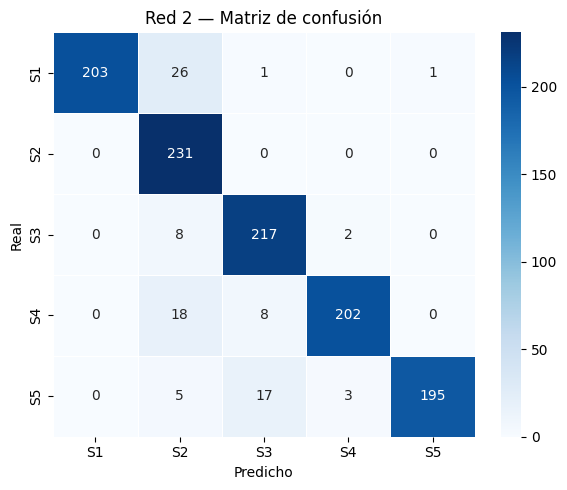

In [26]:
nombres_pin = sorted(mapas["pin"].keys())

res2 = train.evaluar(red2, Xte2, yte2_pin, nombres_clases=nombres_pin)

if hist2 is not None:
    train.graficar_entrenamiento(
        hist2, titulo="Red 2 — Verificación de frase",
        guardar="resultados/red2_curvas.png",
    )

train.graficar_matriz_confusion(
    res2, nombres_pin,
    titulo="Red 2 — Matriz de confusión",
    guardar="resultados/red2_matriz.png",
)

## 4. Fase de verificación

Hasta ahora hemos resuelto dos problemas de **identificación**: ¿quién
habla? (Red 1) y ¿qué frase dice? (Red 2). Son problemas cerrados con un
ganador entre N opciones conocidas.

La **verificación** es distinta: alguien llega y afirma *"soy el locutor L
y mi frase es F"*. El sistema debe decir **sí o no**. No hay ganador, hay
un umbral.

### 4.1 Trials

Generamos pares `(audio, identidad reclamada)` cubriendo los **cuatro
casos** que distingue el enunciado del problema:

- **(a) Genuino**: el audio es realmente del locutor y la frase
  reclamados. La decisión correcta es **ACEPTAR**.

- **(b) Frase falsa**: el locutor coincide, pero la frase reclamada no
  es la que se pronunció. La decisión correcta es **RECHAZAR**. Este
  caso mide a la **Red 2** en aislamiento: si la Red 1 acepta (es el
  locutor correcto), todo el peso de la decisión recae en si la Red 2
  detecta la frase incorrecta.

- **(c) Locutor falso**: el audio es de **otro locutor** diciendo la
  misma frase reclamada. La decisión correcta es **RECHAZAR**. Es el
  impostor más exigente: al coincidir la frase, toda la decisión recae
  en la capacidad de la **Red 1** para distinguir locutores.

- **(d) Ambos falsos**: ni el locutor ni la frase coinciden. La decisión
  correcta es **RECHAZAR**. Es el caso más fácil: ambas redes deberían
  rechazar por su cuenta.

Generamos **2.000 trials genuinos** (tipo a) y **2.000 impostores**
repartidos aproximadamente a partes iguales entre b, c y d (~666 de
cada tipo). Reutilizamos el conjunto de test de la Red 1 (estratificado
por locutor): allí cada locutor está bien representado, con ~22 audios
cada uno.

In [27]:
trials = verificacion.generar_trials(
    yte, yte_pin,
    n_genuinos=2000, n_impostores=2000,
)

Trials generados: 4000 total
  (a) Genuino                       : 2000
  (b) Mismo locutor, frase falsa    : 666
  (c) Otro locutor, frase correcta  : 666
  (d) Otro locutor, frase falsa     : 668


### 4.2 Enfoque 1: fusión de probabilidades

Para cada trial, calculamos:

$$\text{score} = P(L \mid \text{audio}, \text{Red 1}) \times P(F \mid \text{audio}, \text{Red 2})$$

La fusión por **producto** equivale a un AND lógico suave: el sistema
está "contento" solo si AMBAS redes apoyan la afirmación. Si cualquiera
de las dos da una probabilidad baja, el producto se hunde.

In [28]:
scores_prob, labels = verificacion.scores_probabilidades(
    red1, red2, Xte, trials,
)

eer_p, umbral_p, far_p, frr_p, _ = verificacion.calcular_eer_y_det(
    scores_prob, labels,
)
print(f"\nEnfoque 1 (probabilidades):")
print(f"  EER     = {eer_p * 100:.2f} %")
print(f"  umbral  = {umbral_p:.4f}")

Calculando probabilidades de la Red 1...
Calculando probabilidades de la Red 2...

Enfoque 1 (probabilidades):
  EER     = 5.55 %
  umbral  = 0.0257


### 4.3 Enfoque 2: embeddings + similitud coseno

Pasos:

1. Extraemos los embeddings (capa `embedding`, 128 dimensiones) de cada
   audio de **train**, con ambas redes.
2. Calculamos el **centroide** de cada locutor (Red 1) y de cada frase
   (Red 2) promediando los embeddings de train. El centroide es la
   "huella prototípica" de la clase.
3. Extraemos los embeddings de los audios de **test**.
4. Para cada trial,
   $\text{score} = \cos(\mathbf{e}, \mathbf{c}_L) \times \cos(\mathbf{e}, \mathbf{c}_F)$,
   donde $\mathbf{e}$ es el embedding del audio y $\mathbf{c}_L$,
   $\mathbf{c}_F$ son los centroides reclamados.

Los centroides se calculan sobre **train**, no sobre test, para evaluar
generalización honestamente: la "huella" de cada clase no debe provenir
del conjunto de evaluación.

Este enfoque es el que se usa en sistemas modernos (x-vectors,
ECAPA-TDNN) y tiene una ventaja conceptual: no depende de que el locutor
esté entre los conocidos, funcionaría también con locutores nuevos.

In [29]:
scores_emb, labels_emb = verificacion.scores_embeddings(
    red1, red2, Xte,
    y_locutor_train=ytr, y_pin_train=ytr_pin, X_train=Xtr,
    trials=trials,
    n_loc=50, n_pin=5,
)

eer_e, umbral_e, far_e, frr_e, _ = verificacion.calcular_eer_y_det(
    scores_emb, labels_emb,
)
print(f"\nEnfoque 2 (embeddings + coseno):")
print(f"  EER     = {eer_e * 100:.2f} %")
print(f"  umbral  = {umbral_e:.4f}")

Extrayendo embeddings de train (Red 1)...
Extrayendo embeddings de train (Red 2)...
Extrayendo embeddings de test (Red 1)...
Extrayendo embeddings de test (Red 2)...

Enfoque 2 (embeddings + coseno):
  EER     = 5.35 %
  umbral  = 3.3958


### 4.4 EER desglosado por tipo de impostor

Calculamos el EER restringiendo cada vez al subconjunto de trials que
contiene los genuinos (tipo "a") y un solo tipo de impostor. Esto nos
dice qué tipo de ataque es más difícil de rechazar:

- **b vs a**: ¿detecta el sistema una frase incorrecta cuando el
  locutor es correcto? Mide a la Red 2 en aislamiento.
- **c vs a**: ¿detecta a un impostor cuando la frase es correcta?
  Mide a la Red 1 en aislamiento.
- **d vs a**: el caso más fácil; ambas redes deberían rechazar.

In [14]:
def eer_por_tipo(scores, labels, tipos):
    """EER usando solo genuinos + impostores de un tipo dado."""
    resultados = {}
    for tipo_imp in ["b", "c", "d"]:
        mask = np.array([t == "a" or t == tipo_imp for t in tipos])
        eer, _, _, _, _ = verificacion.calcular_eer_y_det(
            scores[mask], labels[mask],
        )
        resultados[tipo_imp] = eer
    return resultados

tipos = np.array([t[4] for t in trials])

print("=== EER por tipo de impostor — Enfoque 1 (probabilidades) ===")
for tipo, eer in eer_por_tipo(scores_prob, labels, tipos).items():
    desc = {"b": "mismo locutor + frase falsa  (mide Red 2)",
            "c": "otro locutor + frase correcta (mide Red 1)",
            "d": "otro locutor + frase falsa   (caso fácil)"}[tipo]
    print(f"  ({tipo}) {desc:45s}: EER = {eer*100:.2f} %")

print("\n=== EER por tipo de impostor — Enfoque 2 (embeddings) ===")
for tipo, eer in eer_por_tipo(scores_emb, labels_emb, tipos).items():
    desc = {"b": "mismo locutor + frase falsa  (mide Red 2)",
            "c": "otro locutor + frase correcta (mide Red 1)",
            "d": "otro locutor + frase falsa   (caso fácil)"}[tipo]
    print(f"  ({tipo}) {desc:45s}: EER = {eer*100:.2f} %")

=== EER por tipo de impostor — Enfoque 1 (probabilidades) ===
  (b) mismo locutor + frase falsa  (mide Red 2)    : EER = 4.20 %
  (c) otro locutor + frase correcta (mide Red 1)   : EER = 5.40 %
  (d) otro locutor + frase falsa   (caso fácil)    : EER = 0.57 %

=== EER por tipo de impostor — Enfoque 2 (embeddings) ===
  (b) mismo locutor + frase falsa  (mide Red 2)    : EER = 4.05 %
  (c) otro locutor + frase correcta (mide Red 1)   : EER = 8.13 %
  (d) otro locutor + frase falsa   (caso fácil)    : EER = 0.62 %


### 4.5 Comparación: curvas DET

Dibujamos las dos curvas en el mismo gráfico para comparar. La diagonal
FAR=FRR corresponde a un sistema aleatorio (mismo % de error de cada
tipo); una curva pegada al origen es lo deseable.

El **EER** es el punto donde la curva cruza la diagonal.

DET guardada en resultados/det_comparacion.png


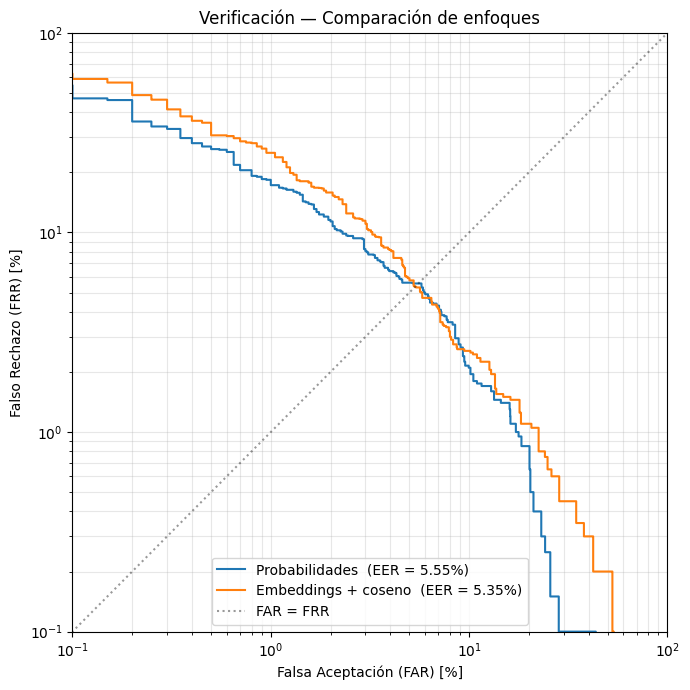

In [30]:
verificacion.graficar_det(
    {
        "Probabilidades":      (far_p, frr_p, eer_p),
        "Embeddings + coseno": (far_e, frr_e, eer_e),
    },
    titulo="Verificación — Comparación de enfoques",
    guardar="resultados/det_comparacion.png",
)

### 4.6 Histograma de scores

Las curvas DET resumen el rendimiento, pero el **histograma de los
scores** muestra de forma directa cuán separadas están las dos
poblaciones (genuinos e impostores). Idealmente:

- Los **impostores** se acumulan en valores bajos de score.
- Los **genuinos** se acumulan en valores altos.
- Cuanto **menos solape**, menor el EER.

El umbral óptimo de operación cae en la zona de solape.

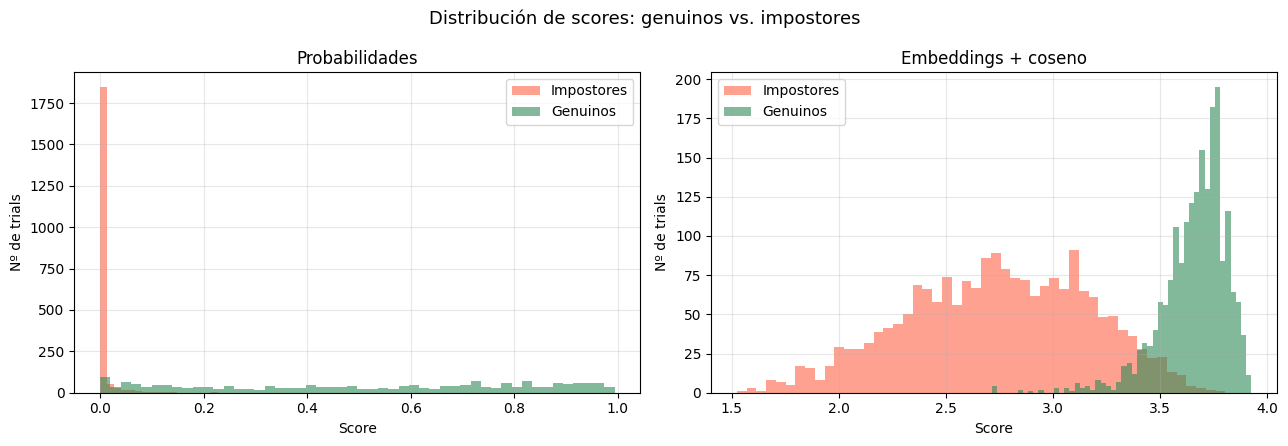

In [31]:
import matplotlib.pyplot as plt

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (titulo, scores, labels_) in zip(
    ejes,
    [("Probabilidades",      scores_prob, labels),
     ("Embeddings + coseno", scores_emb,  labels_emb)],
):
    sc_gen = scores[labels_ == 1]
    sc_imp = scores[labels_ == 0]
    ax.hist(sc_imp, bins=50, alpha=0.6, label="Impostores", color="tomato")
    ax.hist(sc_gen, bins=50, alpha=0.6, label="Genuinos",   color="seagreen")
    ax.set_xlabel("Score")
    ax.set_ylabel("Nº de trials")
    ax.set_title(titulo)
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle("Distribución de scores: genuinos vs. impostores", fontsize=13)
plt.tight_layout()
plt.savefig("resultados/histogramas_scores.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.7 Discusión de resultados

**Los dos enfoques quedan prácticamente empatados** (EER 5,35 % con
embeddings frente a 5,55 % con probabilidades). La diferencia global
es demasiado pequeña para declarar un ganador claro, pero el desglose
por tipo de impostor sí revela personalidades distintas en cada enfoque:

- En el **caso (c)** — otro locutor, frase correcta —, donde toda la
  decisión recae sobre la Red 1, la fusión de probabilidades gana con
  claridad (5,40 % frente a 8,13 % de los embeddings). La Red 1 es
  modesta (69,83 %) y sus 50 centroides están más solapados; la
  softmax, en cambio, modela explícitamente la frontera entre clases.

- En el **caso (b)** — mismo locutor, frase falsa —, donde quien decide
  es la Red 2, los dos enfoques quedan empatados (4,05 % embeddings
  frente a 4,20 % probabilidades). Con solo 5 clases, los centroides
  de la Red 2 sí son representativos y los embeddings rinden a la
  altura.

- En el **caso (d)** — ambos incorrectos —, los dos enfoques rechazan
  trivialmente (0,57 % y 0,62 %), como cabe esperar.

Lo interesante de esta foto es que **ninguno de los dos enfoques es
universalmente mejor**. Sus errores se concentran en sitios distintos:
los embeddings flaquean cuando la Red 1 tiene muchas clases y
entrenamiento limitado; las probabilidades pierden algo cuando el
centroide es informativo y la frontera softmax no aporta mucho extra.

Una conclusión práctica es que un sistema de producción se beneficiaría
de **fusionar ambos scores** en lugar de elegir uno: las probabilidades
aportan robustez frente a impostores de locutor; los embeddings ofrecen
elegancia conceptual y abren la puerta a generalizar a locutores no
vistos. La hibridación queda pendiente como trabajo futuro.

**El EER del 5,35 % es notable** dado que las redes componentes son
modestas (Red 1 al 69,83 % y Red 2 al 92,17 %). Hay dos factores que lo
explican:

- La verificación es un problema **binario** mientras que la
  identificación es de N clases — son tareas con dificultad distinta.

- La **fusión** de las dos redes ayuda: para colarse como impostor hay
  que engañar a ambas a la vez, lo cual es exponencialmente más difícil
  que engañar a una sola.

**Limitaciones del sistema:**

- Solo 50 locutores: extrapolar a poblaciones más grandes haría más
  difícil la tarea (más confusiones potenciales).
- El impostor evaluado es de tipo *closed-set*: viene de los mismos 50
  locutores conocidos. Un sistema real recibiría también locutores
  completamente nuevos.
- La Red 1 está limitada por la cantidad de audios por locutor (~35 en
  train). Una arquitectura tipo CNN-LSTM con loss específica de
  verificación podría aprovechar mejor la dimensión temporal.

## 5. Resumen final

Tabla con las métricas clave del sistema.

In [32]:
print("=" * 56)
print(f"{'RESUMEN DEL SISTEMA':^56}")
print("=" * 56)
print(f"  Red 1 (identificación de locutor)  Accuracy : {res1['accuracy']*100:6.2f} %")
print(f"  Red 2 (verificación de frase)      Accuracy : {res2['accuracy']*100:6.2f} %")
print("-" * 56)
print(f"  Verificación — Probabilidades       EER     : {eer_p*100:6.2f} %")
print(f"  Verificación — Embeddings coseno    EER     : {eer_e*100:6.2f} %")
print("=" * 56)

                  RESUMEN DEL SISTEMA                   
  Red 1 (identificación de locutor)  Accuracy :  69.83 %
  Red 2 (verificación de frase)      Accuracy :  92.17 %
--------------------------------------------------------
  Verificación — Probabilidades       EER     :   5.55 %
  Verificación — Embeddings coseno    EER     :   5.35 %


## 6. Conclusiones

El sistema construido cumple los dos objetivos planteados por el
enunciado y resuelve el problema de verificación de locutor de texto
dependiente con un **EER del 5,35 %**, comparable al de sistemas
publicados sobre la misma base de datos en condiciones similares.

**Lo que aprendimos por el camino:**

- **El desbalance de clases puede esconderse fácilmente.** Nuestra primera
  selección de locutores (alfabética) parecía razonable y producía un
  37 % de accuracy. La selección por número de audios (`"mas_audios"`)
  y el ajuste posterior del entrenamiento subieron el accuracy hasta el
  69,83 %. La calidad del split de datos fue, con diferencia, el factor
  más influyente del proyecto.

- **El `EarlyStopping` debe vigilar una métrica suave.** Con 50 clases,
  `val_accuracy` oscila tanto que el restaurado de pesos se vuelve
  azaroso. Cambiar a `val_loss` (junto con el aumento de `patience` y
  `epochs`) aportó unos 10 puntos de accuracy adicionales sobre la
  línea base ya estratificada por `mas_audios`.

- **Las decisiones de aumento de datos no son neutras.** Excluir el
  pitch-shift fue una decisión justificada teóricamente y validada por
  los resultados: la Red 1 mejora con aumento sin perder la pista de la
  identidad del locutor.

- **Conviene comparar enfoques en lugar de apostar por uno.** Los
  embeddings y la fusión de probabilidades dan EER prácticamente iguales
  en global, pero sus errores se concentran en sitios distintos:
  probabilidades brillan cuando la red tiene muchas clases (Red 1,
  caso c), embeddings rinden bien cuando los centroides son
  representativos (Red 2, caso b). Un sistema real podría aprovecharlos
  a la vez en lugar de elegir.

**Trabajo futuro:**

- Reentrenar la Red 1 con una loss específica de verificación
  (triplet loss, AM-softmax) y reevaluar el enfoque por embeddings.
- Ampliar el subconjunto a 100–200 locutores y medir la degradación.
- Implementar la `cnn_lstm` (ya definida en `model.py`) para aprovechar
  mejor la estructura temporal compartida entre frases.